In [1]:
# Importing Modules
import torch
import numpy as np
import pandas as pd
from src.dataloader import loadData
from src.model import GNNModel
from src.train_test import TrainGNN, TestGNN
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from scipy import stats

In [2]:
######################## DATA-1 ##################################
# Loading ESOL data
esol_train_data = pd.read_csv("data/train/ESOL.csv")
esol_val_data = pd.read_csv("data/val/ESOL.csv")
esol_test_data = pd.read_csv("data/test/ESOL.csv")

######################## DATA-2 ##################################
# Loading RT data
rt_train_data = pd.read_csv("data/train/RT.csv")
rt_val_data = pd.read_csv("data/val/RT.csv")
rt_test_data = pd.read_csv("data/test/RT.csv")

######################## DATA-3 ##################################
# Loading Lipophilicity data
lipophilicity_train_data = pd.read_csv("data/train/Lipophilicity.csv")
lipophilicity_val_data = pd.read_csv("data/val/Lipophilicity.csv")
lipophilicity_test_data = pd.read_csv("data/test/Lipophilicity.csv")

######################## DATA-4 ##################################
# Loading B3DB data
b3db_train_data = pd.read_csv("data/train/B3DB.csv")
b3db_val_data = pd.read_csv("data/val/B3DB.csv")
b3db_test_data = pd.read_csv("data/test/B3DB.csv")

######################## DATA-5 ##################################
# Loading FreeSolv data
freesolv_train_data = pd.read_csv("data/train/FreeSolv.csv")
freesolv_val_data = pd.read_csv("data/val/FreeSolv.csv")
freesolv_test_data = pd.read_csv("data/test/FreeSolv.csv")

In [3]:
datasets_baseline_error = {"ESOL":[0.53, "GraphSAGE"],
            "Lipophilicity":[0.55, "GraphSAGE"],
            "RT":[70.40, "GraphSAGE"],
            "B3DB":[0.56, "GCN"],
            "FreeSolv":[1.02, "GCN"]}

def smiles2features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return [0]*11 
    
    return [
        Descriptors.MolWt(mol),            # Size
        Descriptors.RingCount(mol),        # Ring counts
        Lipinski.NumHDonors(mol),          # H-Bonding
        Lipinski.NumHAcceptors(mol),       # H-Bonding
        mol.GetNumAtoms(),                 # Scale
        mol.GetNumBonds(),                 # Scale
    ]

In [4]:
def RunGNN(train_data, val_data, test_data, dataName, modelName, params, threshold):

    X_test = test_data["smiles"].to_numpy()
    y_test_orig = test_data["target"].to_numpy()

    h_dim, b_size, lr, d_out, wd, layers = params

    test_loader = loadData(X_test, y_test_orig, batch_size=b_size, shuf=False)
    model = torch.load(f"results/{modelName}_{dataName}.pth", weights_only=False)
    
    y_test_res, y_pred_res = TestGNN(model, test_loader)

    error_run = np.abs(np.array(y_test_res) - np.array(y_pred_res))
    is_high_error = error_run > threshold

    high_smiles = X_test[is_high_error]
    low_smiles = X_test[~is_high_error]

    feature_names = ["MolWt", "Rings", "H-Donors", "H-Acceptors", "Atoms", "Bonds"]

    high_features = np.array([smiles2features(s) for s in high_smiles])
    low_features = np.array([smiles2features(s) for s in low_smiles])

    results_list = []
    for i, name in enumerate(feature_names):
        h_feat = high_features[:, i]
        l_feat = low_features[:, i]
        
        _, p_val = stats.ttest_ind(h_feat, l_feat)
        
        star = ""
        if p_val < 0.001: star = "***"
        elif p_val < 0.01: star = "**"
        elif p_val < 0.05: star = "*"
            
        results_list.append({
            "Feature": name,
            "High Error": np.mean(h_feat),
            "Low Error": np.mean(l_feat),
            "p-value": p_val,
            "Star": star
        })

    df_res = pd.DataFrame(results_list)

    df_plot = df_res.melt(id_vars=['Feature', 'Star'], 
                          value_vars=['High Error', 'Low Error'], 
                          var_name='Group', value_name='MeanValue')

    sns.set_style("whitegrid")
    ax = sns.barplot(data=df_plot, x='Feature', y='MeanValue', hue='Group', palette="coolwarm")

    ax.set_yscale("log")

    for i in range(len(feature_names)):
        max_val = max(df_res.loc[i, 'High Error'], df_res.loc[i, 'Low Error'])
        star_label = df_res.loc[i, 'Star']
        
        if star_label:
            ax.text(i, max_val * 1.1, star_label, 
                    ha='center', va='bottom', color='black', 
                    fontsize=14, fontweight='bold')

    plt.title(f"{dataName} ({modelName})", fontsize=15)
    plt.xticks(rotation=45)
    plt.ylabel("Mean Value (Log Scale)")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    return df_res

In [5]:
# Data dict
datasets = {"ESOL":{"train":esol_train_data, "val":esol_val_data, "test":esol_test_data},
            "Lipophilicity":{"train":lipophilicity_train_data, "val":lipophilicity_val_data, "test":lipophilicity_test_data},
            "RT":{"train":rt_train_data, "val":rt_val_data, "test":rt_test_data},
            "B3DB":{"train":b3db_train_data, "val":b3db_val_data,"test":b3db_test_data},
            "FreeSolv":{"train":freesolv_train_data, "val":freesolv_val_data, "test":freesolv_test_data}
           }

# Models
models = ["GCN", "GAT", "GIN", "GraphSAGE"]

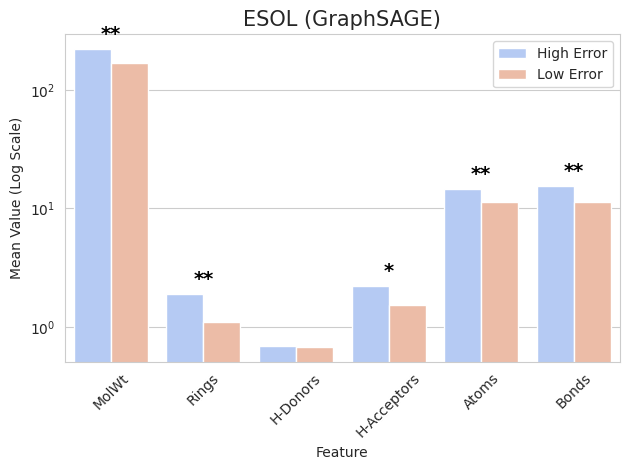

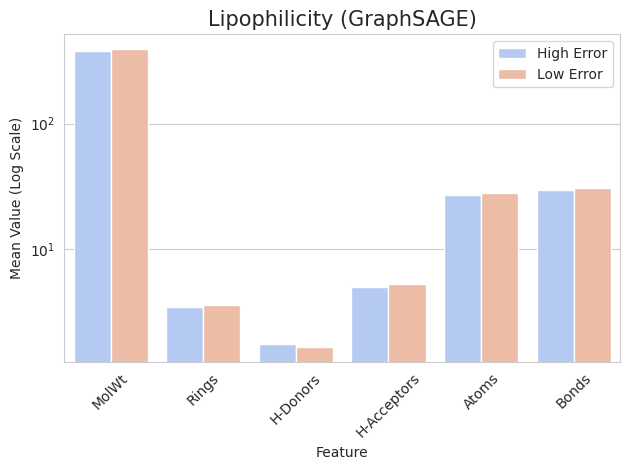

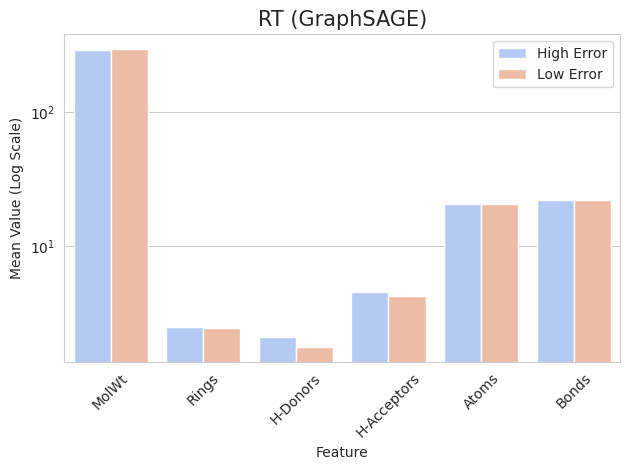

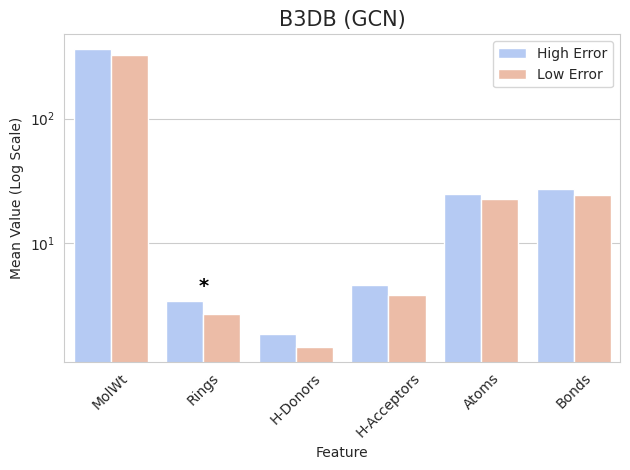

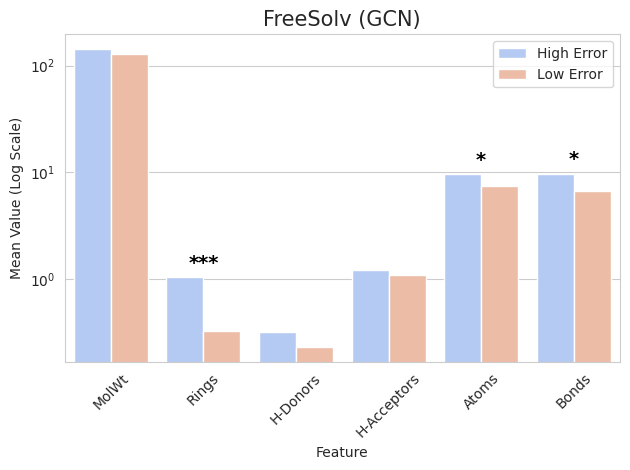

In [6]:
# List to store results
temp_out = []

# Loop for models
for dataName, model in datasets_baseline_error.items():
    # Run Analysis for model and dataset
    threshold, modelName = model
    data = datasets[dataName]
    temp_df = pd.read_csv(f"results/Output_Hyperparameter_Optimization_GNN_{dataName}.csv")
    temp = temp_df[temp_df["Model"]==modelName]
    params = temp.sort_values(by=["RMSE"]).head(1)[["h_dim", "b_size", "lr", "d_out", "w_decay", "layers"]].to_dict('records')[0].values()
    temp_out.append(RunGNN(data["train"], data["val"], data["test"], dataName, modelName, params, threshold))